In [5]:
import numpy as np
import os
import pickle
import networkx as nx
from tqdm import tqdm
from persim import PersImage
from persim import PersistenceImager
import matplotlib.pyplot as plt
import gudhi as gd
from create_local_pd_data import *
import collections
from collections import defaultdict
import collections.abc
collections.Iterable = collections.abc.Iterable

In [6]:
star_fp = os.path.join('..', 'superblue', 'superblue_18', 'star.pkl')
f = open(star_fp, 'rb')
star_dict = pickle.load(f)
f.close()

edge_index = star_dict['edge_index']

node_features_fp = os.path.join('..', 'superblue', 'superblue_18', 'node_features.pkl')
f = open(node_features_fp, 'rb')
node_features_dict = pickle.load(f)
f.close()

instance_features = node_features_dict['instance_features']
num_nodes = node_features_dict['num_instances']

In [7]:
G_in = nx.DiGraph(edge_index.tolist())
G_out = G_in.reverse()

nodelist = list(G_in.nodes) # len(nodelist) = 458952

pos_lst = instance_features[:, :2]

pd_dictionary = {}

In [ ]:
# for idx in range(2):
#     if idx == 1:
#         G = G_in
#     else:
#         G = G_out
idx = 0
G = G_out

radius = 6
nodelist = list(G.nodes)
num_nodes = len(pos_lst)
# all_zero_dgms = [[0.0] for i in range(num_nodes)]
all_one_dgms = [[0.0 for idx in range(25)] for i in range(num_nodes)] #25
all_neigh = [[0.0 for idx in range(radius)] for i in range(num_nodes)]

# pimgr_0 = PersistenceImager(pixel_size=3, birth_range=(0, 6), pers_range=(0, 6))
pimgr_1 = PersistenceImager(pixel_size=20, birth_range=(0, 100), pers_range=(0, 100))

for node in tqdm(nodelist):
    if G.degree[node] >= 100:
        neigh_lst, zero_dgm, one_dgm  = gen_local_pd(G, node, radius, pos_lst)
        zero_dgm = zero_dgm/0.01
        one_dgm = one_dgm/0.01
        # L_0 = pimgr_0.transform(zero_dgm)
        L_1 = pimgr_1.transform(one_dgm)
        # all_zero_dgms[node] = L_0.flatten().tolist()
        all_one_dgms[node] = L_1.flatten().tolist()
        all_neigh[node] = neigh_lst
        G.remove_node(node)

nodelist_subset = list(G.nodes)
for node in tqdm(nodelist_subset):
    neigh_lst, zero_dgm, one_dgm = gen_local_pd(G, node, radius, pos_lst)
    if neigh_lst[0] == 0:
        continue
    zero_dgm = zero_dgm/0.01
    one_dgm = one_dgm/0.01
    # L_0 = pimgr_0.transform(zero_dgm)
    L_1 = pimgr_1.transform(one_dgm)
    # all_zero_dgms[node] = L_0.flatten().tolist()
    all_one_dgms[node] = L_1.flatten().tolist()
    all_neigh[node] = neigh_lst

# pd_dictionary[f"all_zero_dgms_{idx}"] = np.array(all_zero_dgms)
pd_dictionary[f"all_one_dgms_{idx}"] = np.array(all_one_dgms)
pd_dictionary[f"all_neigh_{idx}"] = np.array(all_neigh)

100%|██████████| 457201/457201 [03:29<00:00, 2179.05it/s] 
/var/folders/91/hqswr6qn4pbbmwv42z9t2bvh0000gn/T/ipykernel_91338/4042968215.py:45: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  pd_dictionary[f"all_one_dgms_{idx}"] = np.array(all_one_dgms)


In [9]:
pd_dictionary["all_neigh_0"].mean(axis=0)#, pd_dictionary["all_neigh_1"].mean(axis=0)

array([ 2.10105007,  3.54627363,  5.56309209,  8.57683544, 11.57009325,
       16.09797713])

In [11]:
pd_dictionary["all_one_dgms_0"].mean(axis=1)

array([3.15506414, 4.07608004, 4.21710842, 1.33510899, 1.95120263,
       1.76494913, 0.79242807, 0.86123616, 0.72998088])

Feature trace for the 5th feature (flattened index 5):
  Grid position (row, col): (1, 2)
  Birth range: [6.00, 9.00]
  Persistence range: [3.00, 6.00]

6.666666666666666 15.833333333333332


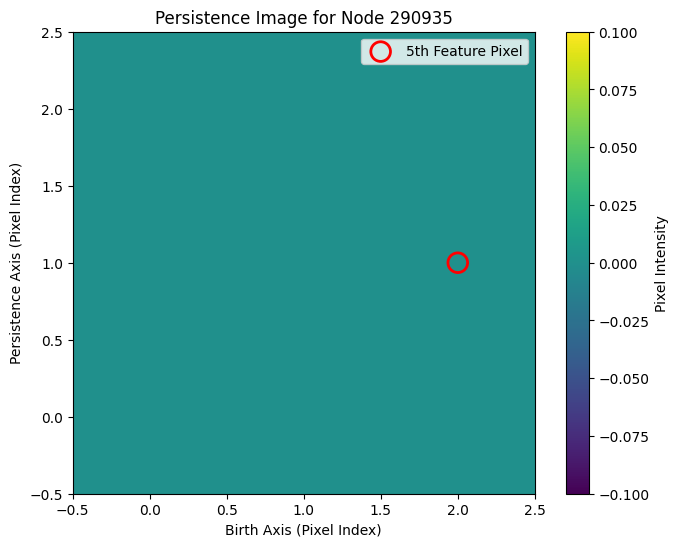

In [22]:
# Choose a node to trace (for example, the first node in nodelist)
# In your actual workflow, you may wish to loop over or select a node of interest.
# for node in tqdm(nodelist):
#     if G.degree[node] >= 100:
#         print('hello')
#         break

node = nodelist[np.random.randint(0, len(nodelist))]

# Generate the local persistence diagram for the chosen node.
# gen_local_pd is assumed to return: neigh_lst, zero_dgm, one_dgm.
neigh_lst, zero_dgm, one_dgm = gen_local_pd(G, node, radius, pos_lst)

# Adjust the diagrams as in your code (scaling by 1/0.01)
zero_dgm = zero_dgm / 0.01
one_dgm = one_dgm / 0.01

# Transform the one-dimensional persistence diagram into a persistence image.
L_1 = pimgr_1.transform(one_dgm)

# Reshape the flattened persistence image back into its 2D grid form.
L1_image = L_1
im_size = L1_image.shape

# --- Trace the Origin of the 5th Feature ---
# Note: Python uses zero-based indexing, so the 5th feature is at index 4.
flat_idx = 5
rows, cols = im_size
row_idx = flat_idx // cols
col_idx = flat_idx % cols

# Using the PersistenceImager parameters, compute the coordinate ranges for this pixel.
birth_min, birth_max = pimgr_1.birth_range
pers_min, pers_max = pimgr_1.pers_range
pixel_width_birth = (birth_max - birth_min) / pimgr_1.pixel_size
pixel_width_pers = (pers_max - pers_min) / pimgr_1.pixel_size

pixel_birth_start = birth_min + col_idx * pixel_width_birth
pixel_birth_end   = pixel_birth_start + pixel_width_birth
pixel_pers_start  = pers_min + row_idx * pixel_width_pers
pixel_pers_end    = pixel_pers_start + pixel_width_pers

print(f"Feature trace for the 5th feature (flattened index {flat_idx}):")
print(f"  Grid position (row, col): ({row_idx}, {col_idx})")
print(f"  Birth range: [{pixel_birth_start:.2f}, {pixel_birth_end:.2f}]")
print(f"  Persistence range: [{pixel_pers_start:.2f}, {pixel_pers_end:.2f}]\n")

targets_fp = os.path.join('..', 'superblue', 'superblue_18', 'targets.pkl')
f = open(targets_fp, 'rb')
targets_dict = pickle.load(f)
f.close()

print(targets_dict['demand'][node], targets_dict['capacity'][node])

# --- Visualize the Persistence Image ---
plt.figure(figsize=(8, 6))
plt.imshow(L1_image, origin='lower', cmap='viridis')
plt.colorbar(label="Pixel Intensity")
plt.title(f"Persistence Image for Node {node}")
plt.xlabel("Birth Axis (Pixel Index)")
plt.ylabel("Persistence Axis (Pixel Index)")

# Highlight the pixel corresponding to the 5th feature.
plt.scatter(col_idx, row_idx, s=200, facecolors='none', edgecolors='red', linewidths=2,
            label="5th Feature Pixel")
plt.legend()
plt.show()

In [84]:
targets_fp = os.path.join('..', 'superblue', 'superblue_18', 'targets.pkl')
f = open(targets_fp, 'rb')
targets_dict = pickle.load(f)
f.close()

targets_dict['demand'][node], targets_dict['capacity'][node]

(17.5, 15.833333333333332)